# Generalized Lagrangian Neural Networks (GLNN) — Paper Baseline
## Damped Harmonic Oscillator System

This notebook implements the **Generalized Lagrangian Neural Network (GLNN)** from the paper on physics-informed neural networks for non-conservative systems.

### System Dynamics
The experiment uses a **1D damped harmonic oscillator**:
$$\ddot{q} + a\dot{q} + \omega^2 q = 0$$

where:
- $\omega = 1.0$ (natural frequency)
- $a = 0.02$ (damping coefficient)
- Initial conditions: uniformly distributed in $[-1, 1]^2$

### Experiment Plan
1. **Generate synthetic data**: 40 trajectories × 200 time steps each = 8,000 point pairs
2. **Normalize**: Z-score normalization using training statistics only
3. **Train GLNN**: Standard MSE loss, 300 epochs, constant LR=0.001, batch_size=1000
4. **Evaluate**: One-step and rollout predictions on test set

### GLNN Architecture
- **Lagrangian Network (L-net)**: 3-layer Dense network (hidden=200) → scalar Lagrangian
- **Force Network (F-net)**: 3-layer Dense network (hidden=200) → d-dimensional non-conservative forces
- **Dynamics**: Generalized Lagrange equation with standard PyTorch autodiff (no vmap, no force library)

In [ ]:
# ── Cell 2
# Core utilities
import os
import time
import warnings
import random
from argparse import Namespace

# Data & Numerical Computing
import numpy as np

# Plotting & Visualization
import matplotlib.pyplot as plt

# JAX Framework
import jax
import jax.numpy as jnp
from jax import random as jax_random

# ─────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────

# Suppress warnings and set plotting style
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'ggplot')

# Global JAX random key
JAX_KEY = None

def seed_everything(seed=42):
    global JAX_KEY
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

    # JAX random key initialization
    JAX_KEY = jax_random.PRNGKey(seed)

seed_everything(42)

# ─────────────────────────────────────────────────────────────
print('✓ All required libraries imported and configured.')

✓ All required libraries imported and configured.


In [ ]:
# ── Cell 3 (physical system)

# System and data configuration
DIMENSION, OMEGA = 1, 1.0
DAMPING_COEFF = 0.02  # Friction coefficient (matches GLNN paper)
N_TRAJECTORIES = 40   # Number of trajectories
PTS_PER_TRAJECTORY = 201  # Points per trajectory
H_DATA_GEN = 0.05  # Time step for data generation (matches paper)

def rk4_step(q, dynamics_fn, dt):
    """Perform a single RK4 integration step.

    Args:
        q: Current state
        dynamics_fn: Function that computes state derivatives
        dt: Time step

    Returns:
        q_new: Updated state after RK4 step
        deriv: Derivative at current state
    """
    k1 = dynamics_fn(q)
    k2 = dynamics_fn(q + 0.5 * dt * k1)
    k3 = dynamics_fn(q + 0.5 * dt * k2)
    k4 = dynamics_fn(q + dt * k3)

    q_new = q + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    deriv = dynamics_fn(q)  # Derivative at current state

    return q_new, deriv

def _damped_HO_trajectory(n_points, d, omega=1.0, damping=1.0, dt=0.05, q0=None):
    """Generate a single trajectory using RK4 integration (JAX).

    Equation of Motion: q̈ = -ω²*q - a*q̇

    Args:
        n_points (int): Number of time steps to integrate
        d (int): Degrees of freedom (state dimension = 2*d: [q, q̇])
        omega (float): Natural frequency (default=1.0)
        damping (float): Damping coefficient (default=1.0)
        dt (float): Time step for RK4 integration (default=0.05)
        q0 (jnp.ndarray, optional): Initial state [q₀, q̇₀]. If None, randomly initialized from Uniform[-1,1]²

    Returns:
        tuple:
            - states (jnp.ndarray): Shape (n_points, 2*d) - full trajectory [q, q̇] at each time step (open rollout)
            - derivs (jnp.ndarray): Shape (n_points-1, 2*d) - state derivatives [q̇, q̈] at each time step (open rollout)
    """
    if q0 is None:
        # JAX: uniform initialization using global JAX_KEY
        q0 = jax_random.uniform(JAX_KEY, shape=(2 * d,), minval=-1.0, maxval=1.0)

    def dynamics(state):
        """Compute state derivatives: [q̇, q̈]"""
        q_pos, q_vel = state[:d], state[d:]
        q_acc = -omega**2 * q_pos - damping * q_vel
        return jnp.concatenate([q_vel, q_acc])

    states = [q0]
    derivs = []
    q = q0

    for _ in range(n_points - 1):
        q_new, deriv = rk4_step(q, dynamics, dt)
        states.append(q_new)
        derivs.append(deriv)
        q = q_new

    return jnp.stack(states), jnp.stack(derivs)

# def _damped_HO_trajectory(n_points, d, omega=1.0, damping=1.0, dt=0.05, q0=None):
#     """Generate a single trajectory using RK4 integration (JAX).

#     Equation of Motion (Simple Pendulum): q̈ = -ω²*sin(q) - a*q̇

#     Args:
#         n_points (int): Number of time steps to integrate
#         d (int): Degrees of freedom (state dimension = 2*d: [q, q̇])
#         omega (float): Natural frequency sqrt(g/L) (default=1.0)
#         damping (float): Damping coefficient (default=1.0)
#         dt (float): Time step for RK4 integration (default=0.05)
#         q0 (jnp.ndarray, optional): Initial state [q₀, q̇₀]. If None, randomly initialized from Uniform[-1,1]²

#     Returns:
#         tuple:
#             - states (jnp.ndarray): Shape (n_points, 2*d) - full trajectory [q, q̇] at each time step
#             - derivs (jnp.ndarray): Shape (n_points-1, 2*d) - state derivatives [q̇, q̈] at each time step
#     """
#     if q0 is None:
#         # JAX: uniform initialization using global JAX_KEY
#         q0 = jax_random.uniform(JAX_KEY, shape=(2 * d,), minval=-1.0, maxval=1.0)

#     def dynamics(state):
#         """Compute state derivatives: [q̇, q̈]"""
#         q_pos, q_vel = state[:d], state[d:]
#         # Changed to Pendulum dynamics: added jnp.sin() to q_pos
#         q_acc = -omega**2 * jnp.sin(q_pos) - damping * q_vel
#         return jnp.concatenate([q_vel, q_acc])

#     states = [q0]
#     derivs = []
#     q = q0

#     for _ in range(n_points - 1):
#         q_new, deriv = rk4_step(q, dynamics, dt)
#         states.append(q_new)
#         derivs.append(deriv)
#         q = q_new

#     return jnp.stack(states), jnp.stack(derivs)

print('Configured Damped Harmonic Motion Data (Paper Baseline) - JAX:')
print(f'  State: {DIMENSION}D [q, q_dot] | ω: {OMEGA} | a (damping): {DAMPING_COEFF}')
print(f'  Trajectories: {N_TRAJECTORIES} × {PTS_PER_TRAJECTORY} points = {N_TRAJECTORIES * PTS_PER_TRAJECTORY} point pairs')
print(f'  Initial conditions: Uniform in [-1, 1]²')


Configured Damped Harmonic Motion Data (Paper Baseline) - JAX:
  State: 1D [q, q_dot] | ω: 1.0 | a (damping): 0.02
  Trajectories: 40 × 201 points = 8040 point pairs
  Initial conditions: Uniform in [-1, 1]²


In [ ]:
# ── Cell 4: Generate & Normalize Synthetic Data

print('Generating damped harmonic motion data (40 trajectories × 200 points)...')

all_states = []
all_derivs = []

for traj_idx in range(N_TRAJECTORIES):
    states, derivs = _damped_HO_trajectory(
        PTS_PER_TRAJECTORY, DIMENSION,
        omega=OMEGA, damping=DAMPING_COEFF, dt=H_DATA_GEN
    )
    all_states.append(np.array(states))
    all_derivs.append(np.array(derivs))

# For plotting purposes, one trajectory data is kept aside
gt_trajectory = all_states[0]
gt_derivatives = all_derivs[0]
gt_initial_condition = gt_trajectory[0]

# Training & Test Data
x_data = np.concatenate([states[:-1] for states in all_states], axis=0)
# y_data = np.concatenate([derivs for derivs in all_derivs], axis=0)
y_data = np.concatenate([states[1:] for states in all_states], axis=0)

split_idx = len(x_data) // 2
x_tr, y_tr = x_data[:split_idx], y_data[:split_idx]
x_te, y_te = x_data[split_idx:], y_data[split_idx:]

print(f"""✓ Data generated: {N_TRAJECTORIES} × {PTS_PER_TRAJECTORY} = {len(x_data)} pairs
  Train/Test: {len(x_tr)} / {len(x_te)}
  Reference trajectory (Trajectory 0): q₀={gt_initial_condition[0]:.4f}, q̇₀={gt_initial_condition[1]:.4f}""")

Generating damped harmonic motion data (40 trajectories × 200 points)...
✓ Data generated: 40 × 201 = 8000 pairs
  Train/Test: 4000 / 4000
  Reference trajectory (Trajectory 0): q₀=-0.0226, q̇₀=0.3596


In [ ]:
# ── Cell 5
# Verify and summarize damped harmonic motion data

pos_vel_corr = np.corrcoef(x_tr[:, 0], x_tr[:, 1])[0, 1]
deriv_stats = y_tr.mean(axis=0), y_tr.std(axis=0)

print(f"""--- Damped Harmonic Motion Data Summary ---
Physics Setup:
  System: 1D Damped Harmonic Oscillator
  EOM: q̈ + aq̇ + ω²q = 0  (where a={DAMPING_COEFF}, ω={OMEGA})
  Initial conditions: Uniform in [-1, 1]²

Dataset Configuration (matches GLNN paper Table 1):
  Trajectories: {N_TRAJECTORIES}
  Points per trajectory: {PTS_PER_TRAJECTORY}
  Time step (dt): {H_DATA_GEN}
  Total point pairs: {len(x_data)}
  Train/Test split: 1:1 → Train={len(x_tr)}, Test={len(x_te)}

[Raw Statistics: Mean | Std | Min | Max]
  Position q:  {x_tr[:, 0].mean():.4f} | {x_tr[:, 0].std():.4f} | {x_tr[:, 0].min():.4f} | {x_tr[:, 0].max():.4f}
  Velocity q̇: {x_tr[:, 1].mean():.4f} | {x_tr[:, 1].std():.4f} | {x_tr[:, 1].min():.4f} | {x_tr[:, 1].max():.4f}

[Derivative (Target) Statistics]
  Mean: {deriv_stats[0].round(6)}
  Std:  {deriv_stats[1].round(6)}

[Physics Verification]
  Position-Velocity correlation: {pos_vel_corr:.4f} (weak, expected for oscillatory motion)
  Velocity magnitude (train): mean={np.abs(x_tr[:, 1]).mean():.4f}, std={np.abs(x_tr[:, 1]).std():.4f}
-------------------------------------------""")

--- Damped Harmonic Motion Data Summary ---
Physics Setup:
  System: 1D Damped Harmonic Oscillator
  EOM: q̈ + aq̇ + ω²q = 0  (where a=0.02, ω=1.0)
  Initial conditions: Uniform in [-1, 1]²

Dataset Configuration (matches GLNN paper Table 1):
  Trajectories: 40
  Points per trajectory: 201
  Time step (dt): 0.05
  Total point pairs: 8000
  Train/Test split: 1:1 → Train=4000, Test=4000

[Raw Statistics: Mean | Std | Min | Max]
  Position q:  0.0648 | 0.2276 | -0.3433 | 0.3542
  Velocity q̇: -0.0121 | 0.2478 | -0.3487 | 0.3599

[Derivative (Target) Statistics]
  Mean: [ 0.064122 -0.015306]
  Std:  [0.228089 0.247096]

[Physics Verification]
  Position-Velocity correlation: 0.0336 (weak, expected for oscillatory motion)
  Velocity magnitude (train): mean=0.2245, std=0.1056
-------------------------------------------


Total dataset size    : 4000 points
Active points (>1e-4) : 4000 points
Dead points (≤1e-4)   : 0 (0.00%)


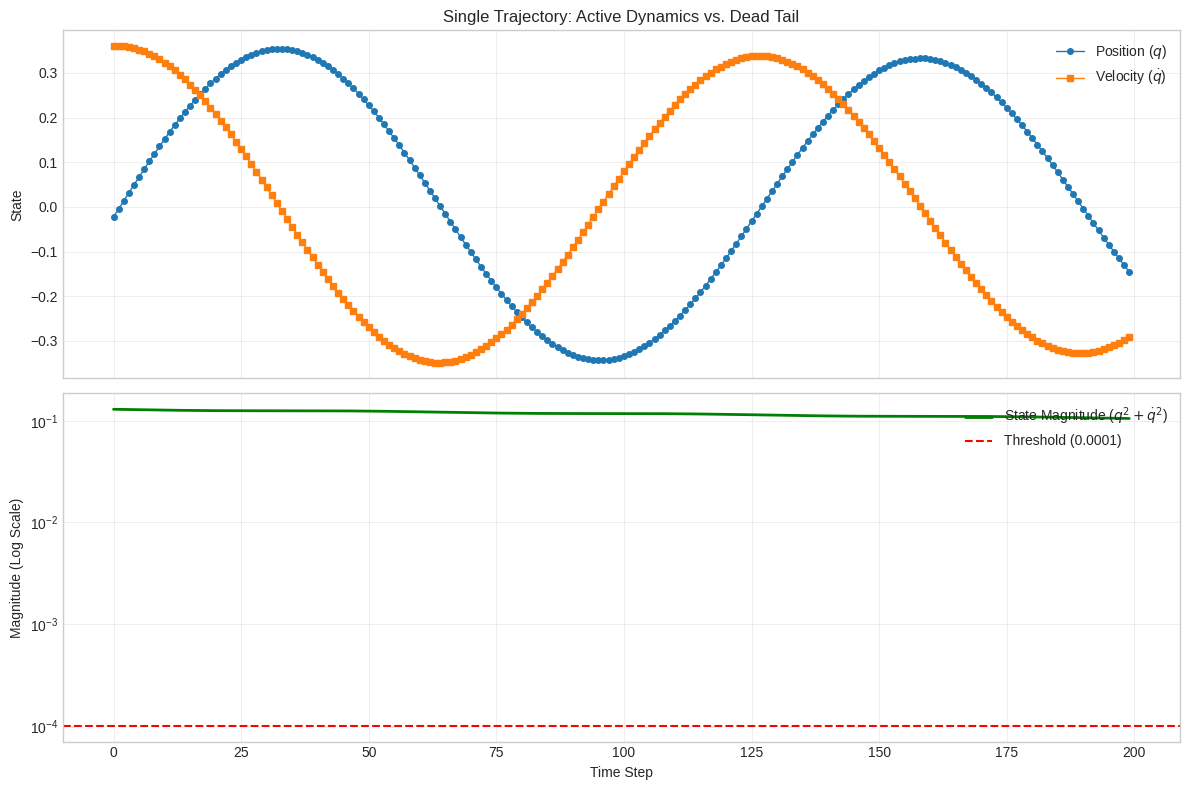

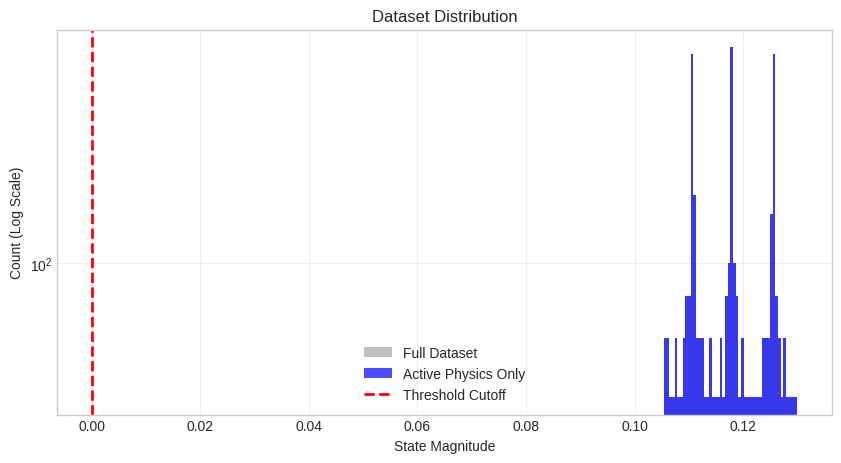

In [ ]:
# ── Cell 6 (Energy Threshold Analysis in JAX)
energy_threshold = 1e-4

# Convert to JAX arrays for computation
x_tr_jax = jnp.array(x_tr)

# 1. Calculate state magnitude (JAX)
state_magnitude_jax = jnp.sum(x_tr_jax**2, axis=-1)
state_magnitude = np.array(state_magnitude_jax)  # Convert back for plotting

# 2. Identify active vs dead points (JAX)
active_indices_jax = state_magnitude_jax > energy_threshold
active_indices = np.array(active_indices_jax)  # Convert back to numpy

# Print the analysis stats
orig_size = len(x_tr)
new_size = int(np.sum(active_indices))
print(f"Total dataset size    : {orig_size} points")
print(f"Active points (>1e-4) : {new_size} points")
print(f"Dead points (≤1e-4)   : {orig_size - new_size} ({(1 - new_size/orig_size)*100:.2f}%)")

# Visualization
time_steps = PTS_PER_TRAJECTORY - 1
single_traj = x_tr[:time_steps]
single_mag = state_magnitude[:time_steps]
is_active = active_indices[:time_steps]
cutoff_idx = int(jnp.argmax(~is_active)) if not is_active.all() else time_steps

# --- Plot A: Time Series & Cutoff ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
t = np.arange(time_steps)

ax1.plot(t, single_traj[:, 0], label='Position ($q$)', color='#1f77b4', linewidth=1, marker='o', markersize=4)
ax1.plot(t, single_traj[:, 1], label='Velocity ($\\dot{q}$)', color='#ff7f0e', linewidth=1, marker='s', markersize=4)
if cutoff_idx < time_steps:
    ax1.axvspan(cutoff_idx, time_steps, color='red', alpha=0.15, label='Dead Tail Region')
ax1.set_ylabel('State')
ax1.set_title('Single Trajectory: Active Dynamics vs. Dead Tail')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Plot B: Magnitude Threshold ---
ax2.plot(t, single_mag, label='State Magnitude ($q^2 + \\dot{q}^2$)', color='green', linewidth=2)
ax2.axhline(energy_threshold, color='red', linestyle='--', label=f'Threshold ({energy_threshold})')
if cutoff_idx < time_steps:
    ax2.axvspan(cutoff_idx, time_steps, color='red', alpha=0.15)
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Magnitude (Log Scale)')
ax2.set_yscale('log')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot C: Dataset Distribution Histogram ---
plt.figure(figsize=(10, 5))
mag_active = state_magnitude[active_indices]
plt.hist(state_magnitude, bins=50, alpha=0.5, label='Full Dataset', color='gray')
plt.hist(mag_active, bins=50, alpha=0.7, label='Active Physics Only', color='blue')
plt.axvline(energy_threshold, color='red', linestyle='dashed', linewidth=2, label='Threshold Cutoff')
plt.yscale('log')
plt.title('Dataset Distribution')
plt.xlabel('State Magnitude')
plt.ylabel('Count (Log Scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
import flax.linen as nn
import jax
import jax.numpy as jnp

DOF = 6           # Degrees of freedom (x, y, z, roll, pitch, yaw)
H   = 1.0/30.0    # DT for JIGSAWS dataset
EPS = 1e-3        # Mass matrix regularization

# ─────────────────────────────────────────────────────────────────────────────
# 1) Lagrangian Network (L-net)
# ─────────────────────────────────────────────────────────────────────────────
class LagrangianNet(nn.Module):
    d: int                # <-- FIXED: No longer hardcoded to 6
    hidden_dim: int = 200

    @nn.compact
    def __call__(self, q, q_dot):
        # -------------------------------------------------------------
        # 1. Potential energy V(q) – scalar (depends only on position)
        # -------------------------------------------------------------
        v_features = nn.Dense(self.hidden_dim)(q)
        v_features = jax.nn.softplus(v_features)
        v_features = nn.Dense(self.hidden_dim)(v_features)
        v_features = jax.nn.softplus(v_features)
        V = nn.Dense(1, kernel_init=jax.nn.initializers.normal(1e-4))(v_features)
        V = jnp.squeeze(V, axis=-1)   # shape: (batch,) or ()

        # -------------------------------------------------------------
        # 2. Mass Matrix Features M(q)
        # -------------------------------------------------------------
        m_features = nn.Dense(self.hidden_dim)(q)
        m_features = jax.nn.softplus(m_features)
        m_features = nn.Dense(self.hidden_dim)(m_features)
        m_features = jax.nn.softplus(m_features)

        # -------------------------------------------------------------
        # 3. Cholesky factor L(q)
        # -------------------------------------------------------------
        # Network outputs d*d numbers (flat) mapped from m_features
        L_flat = nn.Dense(self.d * self.d,
                          kernel_init=jax.nn.initializers.normal(1e-4))(m_features)

        # Reshape to (d, d) – handle both batched and single inputs
        if L_flat.ndim > 1:
            L_mat = L_flat.reshape((-1, self.d, self.d))
            # Extract strictly lower part (zero diagonal)
            lower = jnp.tril(L_mat, k=-1)
            # Force diagonal to be > 0 with softplus + epsilon
            diag = jax.nn.softplus(jnp.diagonal(L_mat, axis1=-2, axis2=-1)) + 1e-3
            diag_mat = jax.vmap(jnp.diag)(diag)
            L = lower + diag_mat
            # M = L @ L^T
            M = jnp.einsum('...ij,...kj->...ik', L, L)
            # Kinetic energy T = 0.5 * q̇^T M q̇
            T = 0.5 * jnp.einsum('...i,...ij,...j->...', q_dot, M, q_dot)
        else:
            L_mat = L_flat.reshape((self.d, self.d))
            lower = jnp.tril(L_mat, k=-1)
            diag = jax.nn.softplus(jnp.diag(L_mat)) + 1e-3
            diag_mat = jnp.diag(diag)
            L = lower + diag_mat
            M = L @ L.T
            T = 0.5 * jnp.dot(q_dot, jnp.dot(M, q_dot))

        # -------------------------------------------------------------
        # 4. Lagrangian = kinetic - potential
        # -------------------------------------------------------------
        return T - V


# ─────────────────────────────────────────────────────────────────────────────
# 2) Force Network (F-net)
# ─────────────────────────────────────────────────────────────────────────────
class ForceNet(nn.Module):
    """
    Force Network: Maps (q, q̇) → d-dimensional non-conservative force F_k
    """
    output_dim: int      # <-- Ensure output_dim matches our input correctly
    hidden_dim: int = 200

    @nn.compact
    def __call__(self, q, q_t):
        x = jnp.concatenate([q, q_t], axis=-1)

        x = nn.Dense(self.hidden_dim)(x)
        x = jax.nn.softplus(x)
        x = nn.Dense(self.hidden_dim)(x)
        x = jax.nn.softplus(x)

        x = nn.Dense(
            features=self.output_dim,
            kernel_init=jax.nn.initializers.normal(stddev=1e-4),
            bias_init=jax.nn.initializers.constant(0.0)
        )(x)

        return x

# ─────────────────────────────────────────────────────────────────────────────
# 3) Hybrid GLNN with both L-net and F-net
# ─────────────────────────────────────────────────────────────────────────────
class HybridGLNNMASS:
    """
    Generalized Lagrangian Neural Network (GLNN) for non-conservative systems.
    """
    def __init__(self, d, hidden_dim=200):
        self.d = d
        # <-- FIXED: Explicitly pass d into both sub-networks
        self.l_net = LagrangianNet(d=d, hidden_dim=hidden_dim)
        self.f_net = ForceNet(output_dim=d, hidden_dim=hidden_dim)

    def init(self, key, x):
        """Initialize both L-net and F-net parameters."""
        q, q_t = jnp.split(x, 2, axis=-1)

        key, subkey = jax.random.split(key)
        l_params = self.l_net.init(subkey, q, q_t)

        key, subkey = jax.random.split(key)
        f_params = self.f_net.init(subkey, q, q_t)

        return {'l_net': l_params, 'f_net': f_params}

    def dstate(self, x, params):
        """
        Compute state derivatives using the generalized Lagrange equation.
        Safely handles both unbatched (d,) and batched (batch, d) inputs.
        """
        # 1. Define the physics for a SINGLE sample
        def _single_dstate(x_single):
            q, q_t = jnp.split(x_single, 2, axis=-1)

            def lagrangian(q_, q_t_):
                return self.l_net.apply(params['l_net'], q_, q_t_)

            def force(q_, q_t_):
                return self.f_net.apply(params['f_net'], q_, q_t_)

            l_grad_q = jax.grad(lagrangian, 0)(q, q_t)              # ∂L/∂q
            l_grad_q_t = jax.grad(lagrangian, 1)(q, q_t)            # ∂L/∂q̇
            l_hess_q_t_q_t = jax.hessian(lagrangian, 1)(q, q_t)     # ∇q̇∇_q̇ L
            l_grad_q_grad_q_t = jax.jacobian(jax.jacobian(lagrangian, 1), 0)(q, q_t)  # ∇_q∇_q̇ L

            F = force(q, q_t)

            mass_matrix = l_hess_q_t_q_t
            rhs = l_grad_q - l_grad_q_grad_q_t @ q_t + F

            q_tt = jnp.linalg.pinv(mass_matrix) @ rhs

            return jnp.concatenate([q_t, q_tt], axis=-1)

        # 2. Automatically map over the batch dimension if it exists
        if x.ndim == 1:
            return _single_dstate(x)
        else:
            return jax.vmap(_single_dstate)(x)

    def forward(self, x, params):
        """Forward pass: compute one-step RK4 integration."""
        def dynamics_fn(state):
            return self.dstate(state, params)

        dt = globals().get('H_DATA_GEN', H)

        q_next, _ = rk4_step(x, dynamics_fn, dt)
        return q_next

# ── Logging ──────────────────────────────────────────────────────────────────
print(f'GLNN configured : DOF={DOF}  dt={float(H):.4f}s  EPS={EPS}')
print(f'L-net           : 3x Dense(200)-Softplus → scalar (Lagrangian)')
print(f'F-net           : 3x Dense(200)-Softplus → d-Dim (Non-conservative Forces)')

GLNN configured : DOF=6  dt=0.0333s  EPS=0.001
L-net           : 3x Dense(200)-Softplus → scalar (Lagrangian)
F-net           : 3x Dense(200)-Softplus → d-Dim (Non-conservative Forces)


In [19]:
# ── Cell 7
#  Training with 4-Stage Curriculum Learning (PyTorch) ──────────

import optax
from functools import partial
import flax.traverse_util as traverse_util

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ──  Loss & Optimization (JAX) ──────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ──  Loss & Optimization (JAX) ──────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def loss_fn(params, model, xb, yb, delta_scale, l2_coef, l1_coef):
    """
    Computes the loss for a single system.
    """
    # 1. Forward pass (Single model)
    # preds shape: (Batch, Features)
    preds = model.forward(xb, params)

    # 2. MSE (Normalized)
    errors = ((preds - yb) / delta_scale)**2
    base_loss = jnp.mean(errors) # Mean over both Batch and Features

    # Note: Consensus loss is removed because there is only one model in this script,
    # so there is no "ensemble agreement" to enforce.

    # 3. Global L2 Regularization
    l2_reg = sum(jnp.sum(p**2) for p in jax.tree_util.tree_leaves(params))

    # 4. Targeted L1 Regularization (Applies ONLY if a force_combiner layer exists)
    flat_params = traverse_util.flatten_dict(params, sep='/')
    l1_reg = 0.0
    for path, weight in flat_params.items():
        if 'force_combiner' in path and 'kernel' in path:
            l1_reg += jnp.sum(jnp.abs(weight))

    # 5. Final optimization target
    total_loss = base_loss + (l2_coef * l2_reg) + (l1_coef * l1_reg)

    # Return as an array of shape (1,) so the logging print string `sys_losses` still works
    return total_loss, jnp.array([base_loss])

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── JIT Compiled Update Step ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

@partial(jax.jit, static_argnames=['model', 'tx'])
def update_step(model, tx, params, opt_state, xb, yb, delta_scale, l2_coef, l1_coef):
    """Calculates gradients, updates optimizer, and returns new params in a pure function."""
    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)

    # Pass the new l1_coef to the gradient function
    (total_loss, system_losses), grads = grad_fn(
        params, model, xb, yb, delta_scale, l2_coef, l1_coef
    )

    # Optimizer step (clipping done in def main)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)

    return params, opt_state, total_loss, system_losses

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── Training Loop ────────────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def train_loop(model, tx, params, opt_state, iter_count, Xs, Ys, delta_scale, key, training_start, batch_size):
    max_idx = len(Xs) - 1
    key, subkey = jax.random.split(key)
    start_idxs = jax.random.randint(subkey, (batch_size,), 0, max_idx)

    xb = Xs[start_idxs]
    yb = Ys[start_idxs]

    # Optimization Step (Updates all models)
    key, dropout_key = jax.random.split(key)
    params, opt_state, total_loss, sys_losses = update_step(
        model, tx, params, opt_state, xb, yb, delta_scale, 1e-5, 1e-5
    )

    if iter_count % 500 == 0:
        total_loss.block_until_ready()
        total_elapsed = time.perf_counter() - training_start
        # Format individual system losses for printing
        sys_loss_str = ", ".join([f"{l:.2e}" for l in sys_losses])
        print(
            f"[Iter {iter_count:5d}] "
            f"Comb_Loss: {total_loss:.2e} | "
            f"Sys MSEs: [{sys_loss_str}] | "
            f"Total Time: {total_elapsed/60:.2f} min"
        )

    iter_count += 1
    return params, opt_state, total_loss, iter_count, key

def main(args, delta_scale, Xs, Ys):
    print(f'Device: {jax.devices()[0]}')

    # 1. Initialize Batched Model State
    model = HybridGLNNMASS(d=args.dimension)

    key = JAX_KEY
    key, init_key = jax.random.split(key)

    # If d=1, features=2 (q, q_dot)
    dummy_x = jnp.ones((args.batch_size, args.dimension * 2))
    params = model.init(init_key, dummy_x)

    loss_history = []
    global_iter = 1
    training_start = time.perf_counter()

    print(f'\n━━━ Training System ━━━')

    # ── STAGE 1: WARMUP (Linear Learning Rate) ──────────────────────────
    print(f'Stage 1: Warmup ({args.iterations_1} iterations)')

    # optax linear schedule equivalent to PyTorch's LinearLR
    schedule1 = optax.linear_schedule(
        init_value=args.lr * 0.1,
        end_value=args.lr,
        transition_steps=args.iterations_1
    )
    tx1 = optax.adamw(learning_rate=schedule1, weight_decay=1e-4) # PyTorch had 1e-4
    tx1 = optax.chain(
        optax.clip_by_global_norm(100.0),
        optax.adamw(learning_rate=schedule1, weight_decay=1e-4)
    )
    opt_state1 = tx1.init(params)

    for step in range(args.iterations_1):
        params, opt_state1, avg_loss, global_iter, key = train_loop(
            model, tx1, params, opt_state1, global_iter, Xs, Ys, delta_scale, key, training_start, args.batch_size
        )
        loss_history.append(float(avg_loss))

    # # ── STAGE 2: FINE-TUNING (Cosine Annealing) ─────────────────────────
    # print(f'Stage 2: Fine-tuning ({args.iterations_2} iterations)')
    # schedule2 = optax.cosine_decay_schedule(init_value=args.lr, decay_steps=args.iterations_2)
    # tx2 = optax.adamw(learning_rate=schedule2, weight_decay=1e-4)
    # opt_state2 = tx2.init(params)

    # for step in range(args.iterations_2):
    #     params, opt_state2, avg_loss, global_iter, key = train_loop(
    #         model, tx2, params, opt_state2, global_iter, Xs, Ys, delta_scale, key, training_start, args.batch_size
    #     )
    #     loss_history.append(float(avg_loss))

    print(f'\n✅ Ensemble Training complete.')
    return np.array(loss_history), params, model

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── TRAINING EXECUTION (JAX) ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# JAX automatically selects the fastest available accelerator (GPU/TPU)
device = jax.devices()[0]
print(f"Using device: {device}")

delta_scale = y_tr.std(axis=0)
delta_scale = np.where(delta_scale < 1e-8, 1.0, delta_scale)

Xs = jnp.array(x_tr, dtype=jnp.float32)
Ys = jnp.array(y_tr, dtype=jnp.float32)
delta_scale_jax = jnp.array(delta_scale, dtype=jnp.float32)

# Create training configuration
# Note: total_systems and l1_weight are omitted here as we simplified
# the architecture to a single system with L2-only regularization previously.
args = Namespace(
    dimension=1,         # Degrees of freedom (d=1 means state size is 2: q, q_dot)
    lr=3e-4,           # Peak learning rate
    iterations_1=3000,   # Warmup steps
    iterations_2=3000,   # Fine-tuning steps
    batch_size=512,
    weight_decay=1e-5,
    pt_dir='./models'
)

# Execute training
print(f'\n{"="*80}')
print(f'{"STARTING MASS ENSEMBLE TRAINING":^80}')
print(f'{"="*80}')

training_start = time.perf_counter()

loss_arr, final_params, dnn = main(args, delta_scale_jax, Xs, Ys)

loss_arr = np.array(loss_arr)
total_time = time.perf_counter() - training_start

print(f'{"="*80}')
print(f'Training complete in {total_time/60:.2f} minutes.')
print(f'Model object is available as `dnn`.')
print(f'Model weights are available as `final_params`.')
print(f'Loss history available as `loss_arr` ({len(loss_arr)} points).')
print(f'{"="*80}\n')

Using device: cuda:0

                        STARTING MASS ENSEMBLE TRAINING                         
Device: cuda:0

━━━ Training System ━━━
Stage 1: Warmup (3000 iterations)
[Iter   500] Comb_Loss: 9.51e-03 | Sys MSEs: [1.58e-07] | Total Time: 0.28 min
[Iter  1000] Comb_Loss: 6.84e-03 | Sys MSEs: [1.44e-06] | Total Time: 0.36 min
[Iter  1500] Comb_Loss: 5.28e-03 | Sys MSEs: [3.70e-08] | Total Time: 0.43 min
[Iter  2000] Comb_Loss: 4.29e-03 | Sys MSEs: [4.20e-08] | Total Time: 0.51 min
[Iter  2500] Comb_Loss: 3.44e-03 | Sys MSEs: [9.37e-08] | Total Time: 0.59 min
[Iter  3000] Comb_Loss: 2.66e-03 | Sys MSEs: [2.73e-06] | Total Time: 0.67 min

✅ Ensemble Training complete.
Training complete in 0.68 minutes.
Model object is available as `dnn`.
Model weights are available as `final_params`.
Loss history available as `loss_arr` (3000 points).



In [20]:
# ── Cell 9: Evaluation Utilities + Wrapper (JAX) ─────────────────────────

class EvalWrapper:
    def __init__(self, model, params):
        """
        Binds the Flax model and trained parameters together for easier evaluation,
        mimicking a stateful PyTorch module API.
        """
        self.model = model
        self.params = params

        # JIT compile batched versions of the functions for maximum evaluation speed
        self.batched_forward = jax.jit(jax.vmap(self.model.forward, in_axes=(0, None)))
        self.batched_dstate = jax.jit(jax.vmap(self.model.dstate, in_axes=(0, None)))

    def _format_input(self, x):
        """Ensures the input is a JAX array and adds a batch dim if necessary."""
        x = jnp.array(x, dtype=jnp.float32)
        is_single = (x.ndim == 1)
        if is_single:
            x = x[None, :]  # Shape (1, Features)
        return x, is_single

    def dstate(self, x):
        x, is_single = self._format_input(x)
        out = self.batched_dstate(x, self.params)
        return out[0] if is_single else out

    def __call__(self, x):
        x, is_single = self._format_input(x)
        out = self.batched_forward(x, self.params)
        return out[0] if is_single else out


def one_step_mse_jax(wrapper, x_data, y_data):
    """Compute one-step MSE prediction error."""
    # Convert to JAX arrays just in case they are numpy
    x_data = jnp.array(x_data, dtype=jnp.float32)
    y_data = jnp.array(y_data, dtype=jnp.float32)

    # Wrapper handles batching automatically
    pred = wrapper(x_data)
    mse = jnp.mean((pred - y_data) ** 2)

    # Return as standard Python float
    return float(mse)


@partial(jax.jit, static_argnames=['model', 'n_steps'])
def _compiled_rollout(model, params, x0, n_steps):
    """Internal JIT-compiled loop for lightning fast rollouts."""
    def step_fn(current_state, _):
        next_state = model.forward(current_state, params)
        # return (carry, output)
        return next_state, next_state

    # lax.scan loops n_steps - 1 times efficiently on the GPU
    _, trajectory = jax.lax.scan(step_fn, x0, None, length=n_steps - 1)

    # Prepend the initial state to the trajectory
    return jnp.concatenate([x0[None, :], trajectory], axis=0)


def rollout_jax(wrapper, x0, n_steps):
    """Generate rollout trajectory starting from x0 for n_steps."""
    x0 = jnp.array(x0, dtype=jnp.float32)

    # Ensure x0 is strictly 1D (Features,)
    if x0.ndim > 1:
        x0 = x0.squeeze()

    # Run compiled rollout
    traj = _compiled_rollout(wrapper.model, wrapper.params, x0, n_steps)

    # Return as a standard NumPy array for easy plotting/external use
    return np.array(traj)

print("✓ Evaluation utilities loaded (JAX simplified wrapper).")

✓ Evaluation utilities loaded (JAX simplified wrapper).


In [21]:
from scipy.integrate import solve_ivp
import numpy as np

# Evaluate on training and test sets (one-step predictions)
# We pass the trained params we got from main() into the wrapper
eval_model = EvalWrapper(dnn, final_params)
mse_tr = one_step_mse_jax(eval_model, x_tr, y_tr)
mse_te = one_step_mse_jax(eval_model, x_te, y_te)

print(f'One-Step MSE:')
print(f'  Train: {mse_tr:.4e}')
print(f'  Test:  {mse_te:.4e}')
print(f'  Gap:   {(mse_te/mse_tr - 1)*100:.1f}%')

def lnn_dynamics_wrapper(t, state_vec):
    """
    Wrapper for Scipy ODE solver: converts (q, q̇) to [q̇, q̈_predicted] using JAX.
    """
    # eval_model.dstate handles the JAX array conversion and evaluation
    dstate_pred = eval_model.dstate(state_vec)

    # solve_ivp expects standard numpy float arrays
    return np.array(dstate_pred)

# Integrate the LNN from the reference initial condition
t_span = (0.0, (len(gt_trajectory) - 1) * H_DATA_GEN)
t_eval = np.arange(len(gt_trajectory)) * H_DATA_GEN

print(f"\n✓ Integrating LNN dynamics using ODE solver:")
print(f"  Initial condition: q={gt_initial_condition[0]:.4f}, q̇={gt_initial_condition[1]:.4f}")
print(f"  Integration time: t ∈ [{t_span[0]:.3f}, {t_span[1]:.3f}] seconds")
print(f"  Number of evaluation points: {len(t_eval)}")

# Solve the ODE
sol = solve_ivp(
    lnn_dynamics_wrapper,
    t_span,
    gt_initial_condition.flatten(),
    t_eval=t_eval,
    method='DOP853',
    dense_output=False,
    max_step=H_DATA_GEN
)

if sol.status != 0:
    print(f"⚠️  ODE solver warning: {sol.message}")

# Extract integrated trajectory
traj_pred = sol.y.T  # Transpose to (n_steps, 2)
traj_gt = gt_trajectory

print(f"✓ ODE integration complete: {len(traj_pred)} timesteps")

One-Step MSE:
  Train: 4.9225e-07
  Test:  4.9225e-07
  Gap:   0.0%

✓ Integrating LNN dynamics using ODE solver:
  Initial condition: q=-0.0226, q̇=0.3596
  Integration time: t ∈ [0.000, 10.000] seconds
  Number of evaluation points: 201
✓ ODE integration complete: 201 timesteps


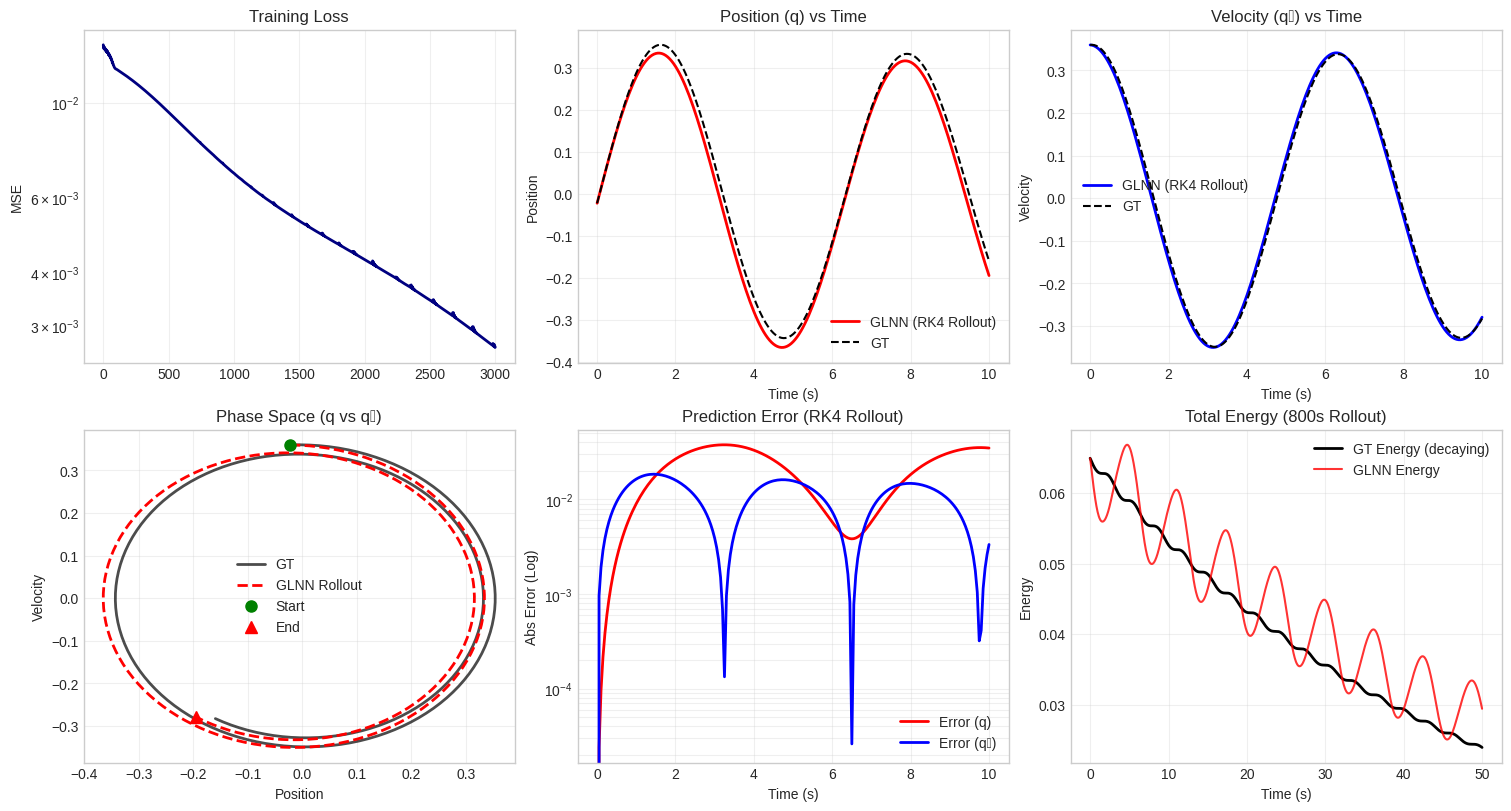


         DAMPED HARMONIC OSCILLATOR - RK4 ROLLOUT DIAGNOSTICS         
Short Trajectory:     201 timesteps (10.050 s)
Mean position error:  2.0314e-02
Max position error:   3.7779e-02
Mean velocity error:  1.0313e-02
Max velocity error:   1.8491e-02
----------------------------------------------------------------------
Long Trajectory (E):  1001 timesteps (50.000 s)
System: ω=1.00, damping=0.0200

Ground Truth Energy Evolution:
  Initial energy: 0.064909
  Final energy:   0.023996
  Energy loss:    0.040913 (63.03%)

GLNN Predicted Energy Evolution:
  Initial energy: 0.064909
  Final energy:   0.029471
  Energy drift:   -0.035438
  Energy loss:    0.035438 (54.60%)

Energy Prediction Error:
  Mean error:     4.487986e-03
  Max error:      9.251792e-03



In [22]:
# ── Cell 11: Visualization & Diagnostics (DAMPED HARMONIC OSCILLATOR) ──────

# Define the dynamics wrapper exclusively for our rk4_step loop
def model_dynamics(state):
    return np.array(eval_model.dstate(state))

# 1. Short Rollout for Standard Plots
current_state = gt_initial_condition
n_steps = len(gt_trajectory)
dt = H_DATA_GEN

rollout_states = [current_state]
for _ in range(n_steps - 1):
    next_state, _ = rk4_step(current_state, model_dynamics, dt)
    rollout_states.append(next_state)
    current_state = next_state

traj_pred = np.array(rollout_states)

# Ensure GT inputs are standard NumPy arrays for plotting
loss_arr = np.asarray(loss_arr)
traj_gt = np.asarray(gt_trajectory)
time_axis = np.arange(n_steps) * dt

q_pred, q_dot_pred = traj_pred[:, 0], traj_pred[:, 1]
q_gt, q_dot_gt = traj_gt[:, 0], traj_gt[:, 1]

# 2. Long Rollout (50 seconds) for Energy Comparison
t_max_long = 50.0
long_steps = int(t_max_long / dt)

# Generate long Ground Truth using the dataset generator
long_gt_states, _ = _damped_HO_trajectory(
    long_steps + 1, DIMENSION,
    omega=OMEGA, damping=DAMPING_COEFF, dt=dt, q0=gt_initial_condition
)
long_gt_states = np.array(long_gt_states)

# Generate long LNN Rollout
current_state_long = gt_initial_condition
long_pred_states = [current_state_long]
for _ in range(long_steps):
    next_state, _ = rk4_step(current_state_long, model_dynamics, dt)
    long_pred_states.append(next_state)
    current_state_long = next_state

long_pred_states = np.array(long_pred_states)
time_axis_long = np.arange(long_steps + 1) * dt

q_gt_long, q_dot_gt_long = long_gt_states[:, 0], long_gt_states[:, 1]
q_pred_long, q_dot_pred_long = long_pred_states[:, 0], long_pred_states[:, 1]

# 3. Create Figure
fig, axs = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

# 1) Training Loss
axs[0, 0].semilogy(loss_arr, 'navy', lw=2)
axs[0, 0].set(title='Training Loss', ylabel='MSE')
axs[0, 0].grid(True, alpha=0.3)

# 2) Position vs Time (Short)
axs[0, 1].plot(time_axis, q_pred, 'r-', lw=2, label='GLNN (RK4 Rollout)')
axs[0, 1].plot(time_axis, q_gt, 'k--', lw=1.5, label='GT')
axs[0, 1].set(title='Position (q) vs Time', xlabel='Time (s)', ylabel='Position')
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# 3) Velocity vs Time (Short)
axs[0, 2].plot(time_axis, q_dot_pred, 'b-', lw=2, label='GLNN (RK4 Rollout)')
axs[0, 2].plot(time_axis, q_dot_gt, 'k--', lw=1.5, label='GT')
axs[0, 2].set(title='Velocity (q̇) vs Time', xlabel='Time (s)', ylabel='Velocity')
axs[0, 2].legend()
axs[0, 2].grid(True, alpha=0.3)

# 4) Phase Space (Short)
axs[1, 0].plot(q_gt, q_dot_gt, 'k-', lw=2, label='GT', alpha=0.7)
axs[1, 0].plot(q_pred, q_dot_pred, 'r--', lw=2, label='GLNN Rollout')
axs[1, 0].plot(q_pred[0], q_dot_pred[0], 'go', ms=8, label='Start')
axs[1, 0].plot(q_pred[-1], q_dot_pred[-1], 'r^', ms=8, label='End')
axs[1, 0].set(title='Phase Space (q vs q̇)', xlabel='Position', ylabel='Velocity')
axs[1, 0].legend()
axs[1, 0].grid(True, alpha=0.3)

# 5) Absolute Error (Short)
abs_err_q = np.abs(q_pred - q_gt)
abs_err_q_dot = np.abs(q_dot_pred - q_dot_gt)
axs[1, 1].semilogy(time_axis, abs_err_q, 'r-', lw=2, label='Error (q)')
axs[1, 1].semilogy(time_axis, abs_err_q_dot, 'b-', lw=2, label='Error (q̇)')
axs[1, 1].set(title='Prediction Error (RK4 Rollout)', xlabel='Time (s)', ylabel='Abs Error (Log)')
axs[1, 1].legend()
axs[1, 1].grid(True, alpha=0.3, which='both')

# 6) Energy calculation for Long Sequence (800 seconds)
# For damped harmonic oscillator: E = ½q̇² + ½ω²q²
energy_gt_long = 0.5 * (q_dot_gt_long**2) + 0.5 * (OMEGA**2) * (q_gt_long**2)
energy_pred_long = 0.5 * (q_dot_pred_long**2) + 0.5 * (OMEGA**2) * (q_pred_long**2)

axs[1, 2].plot(time_axis_long, energy_gt_long, 'k-', lw=2, label='GT Energy (decaying)')
axs[1, 2].plot(time_axis_long, energy_pred_long, 'r-', lw=1.5, alpha=0.8, label='GLNN Energy')
axs[1, 2].set(title='Total Energy (800s Rollout)', xlabel='Time (s)', ylabel='Energy')
axs[1, 2].legend(loc='upper right')
axs[1, 2].grid(True, alpha=0.3)

plt.show()

# ── Diagnostics Printout ────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"{'DAMPED HARMONIC OSCILLATOR - RK4 ROLLOUT DIAGNOSTICS':^70}")
print(f"{'='*70}")
print(f"Short Trajectory:     {n_steps} timesteps ({n_steps * dt:.3f} s)")
print(f"Mean position error:  {abs_err_q.mean():.4e}")
print(f"Max position error:   {abs_err_q.max():.4e}")
print(f"Mean velocity error:  {abs_err_q_dot.mean():.4e}")
print(f"Max velocity error:   {abs_err_q_dot.max():.4e}")
print("-" * 70)
print(f"Long Trajectory (E):  {long_steps+1} timesteps ({t_max_long:.3f} s)")
print(f"System: ω={OMEGA:.2f}, damping={DAMPING_COEFF:.4f}")
print(f"\nGround Truth Energy Evolution:")
print(f"  Initial energy: {energy_gt_long[0]:.6f}")
print(f"  Final energy:   {energy_gt_long[-1]:.6f}")
print(f"  Energy loss:    {(energy_gt_long[0] - energy_gt_long[-1]):.6f} ({(1 - energy_gt_long[-1]/energy_gt_long[0])*100:.2f}%)")
print(f"\nGLNN Predicted Energy Evolution:")
print(f"  Initial energy: {energy_pred_long[0]:.6f}")
print(f"  Final energy:   {energy_pred_long[-1]:.6f}")
print(f"  Energy drift:   {(energy_pred_long[-1] - energy_pred_long[0]):.6f}")
print(f"  Energy loss:    {(energy_pred_long[0] - energy_pred_long[-1]):.6f} ({(1 - energy_pred_long[-1]/energy_pred_long[0])*100:.2f}%)")
print(f"\nEnergy Prediction Error:")
print(f"  Mean error:     {np.mean(np.abs(energy_pred_long - energy_gt_long)):.6e}")
print(f"  Max error:      {np.max(np.abs(energy_pred_long - energy_gt_long)):.6e}")
print(f"{'='*70}\n")

In [23]:
# ── Cell 12: Summary (JAX) ──────────────────────────────────────────────────

# Count total parameters in the JAX parameter PyTree
num_params = sum(p.size for p in jax.tree_util.tree_leaves(final_params))

print(f"""
Training Summary:
  System: ω={OMEGA}, a={DAMPING_COEFF}
  Data: {N_TRAJECTORIES} × {PTS_PER_TRAJECTORY} points
  Train/Test: {len(x_tr)} / {len(x_te)}

Performance:
  Train MSE: {mse_tr:.4e}
  Test MSE:  {mse_te:.4e}
  Gap:       {(mse_te/mse_tr - 1)*100:.1f}%

Model: {num_params:,} parameters
✓ GLNN training complete
""")


Training Summary:
  System: ω=1.0, a=0.02
  Data: 40 × 201 points
  Train/Test: 4000 / 4000

Performance:
  Train MSE: 4.9225e-07
  Test MSE:  4.9225e-07
  Gap:       0.0%

Model: 122,603 parameters
✓ GLNN training complete

